In [1]:
import sys
import os

# Add the parent directory of the current notebook to sys.path
sys.path.append(os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))

In [1]:
result = {
    "prediction" : "truck",
    "confidence" : 0.1
}

In [3]:
result['confidence']

0.1

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [3]:
train_transform = transforms.Compose([
    # transforms.Resize(size = (224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [4]:
test_transform = transforms.Compose([
    # transforms.Resize(size = (224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [5]:
trainset = torchvision.datasets.CIFAR10(
    root = '../data',
    train = True,
    transform=train_transform,
    download=False
)
testset = torchvision.datasets.CIFAR10(
    root = '../data',
    train = False,
    transform = test_transform,
    download=False
)

c:\Users\vansh\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [6]:
train_dataloader = torch.utils.data.DataLoader(
    dataset = trainset,
    batch_size = 256,
    shuffle= True,
    num_workers=os.cpu_count()
)

test_dataloader = torch.utils.data.DataLoader(
    dataset = testset,
    shuffle=False,
    num_workers=os.cpu_count(),
    batch_size=256
)

In [7]:
import numpy as np

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].


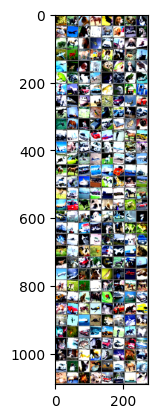

frog  dog   bird  horse


In [8]:
# Class labels
classes = ('plane', 'car', 'bird', 'cat', 'deer', 
           'dog', 'frog', 'horse', 'ship', 'truck')

# 4. Visualize a batch of images
def imshow(img):
    img = img / 2 + 0.5  # Unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Get a batch of training data
dataiter = iter(train_dataloader)
images, labels = next(dataiter)

# Show images
imshow(torchvision.utils.make_grid(images))
# Print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

In [17]:
import torch
import torchvision.models as models

# Load ResNet18 with the best available pretrained weights
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

In [18]:
import torch.nn as nn

In [19]:
model.fc = nn.Linear(
    in_features = model.fc.in_features,
    out_features=10 
)

In [ ]:
# option 1: fine-tuning 
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

In [12]:
device = 'cuda' if torch.cuda.is_available() else 'cpu' 
device 

'cuda'

In [22]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
    # Put the model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0
    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        # Send data to the target device 
        X, y = X.to(device), y.to(device)

        # 1. Forward pass 
        y_pred = model(X)

        # 2. Calculate and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward 
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate metrics across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim = 1), dim = 1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss /= len(dataloader)
    train_acc /= len(dataloader)
    return train_loss, train_acc 

In [23]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
    # Put model in eval model
    model.eval()

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference mode
    with torch.inference_mode():
        # Loop through dataloader batches
        for batch, (X, y) in enumerate(dataloader):
            # Send data to target device
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn (test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim = 1)
            test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))

        # Adjust metrics to get average loss and accuracy per batch
        test_loss /= len(dataloader)
        test_acc /= len(dataloader)
        return test_loss, test_acc

In [24]:
# Create a train function to evaluate train_step() and test_step()
from tqdm.auto import tqdm 
# Take in various parameters required for training and test steps
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs:int = 5):
    
    model = model.to(device=device)
    # 2. Create empty results dictionary
    results = {"train_loss": [],
               "train_acc": [],
               "test_loss": [],
               "test_acc": []
               }
    # 3. Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model = model,
                                           dataloader = train_dataloader,
                                           loss_fn = loss_fn,
                                           optimizer=optimizer)
        test_loss, test_acc = test_step(model = model,
                                        dataloader=test_dataloader,
                                        loss_fn=loss_fn)
        

        # 4. Print out what's happening
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # 5. Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    return results    

c:\Users\vansh\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [25]:
from torch.utils.data import Subset, DataLoader
import numpy as np

# Small subsets
train_subset = Subset(
    trainset,
    indices=np.random.choice(
        len(trainset),
        2000,
        replace=False
    )
)

test_subset = Subset(
    testset,
    indices=np.random.choice(
        len(testset),
        500,
        replace=False
    )
)

small_train_dataloader = DataLoader(
    train_subset,
    batch_size=32,
    shuffle=True
)

small_test_dataloader = DataLoader(
    test_subset,
    batch_size=32,
    shuffle=False
)

In [26]:
len(train_dataloader), len(small_train_dataloader)

(196, 63)

In [27]:
len(test_dataloader), len(small_test_dataloader)

(40, 16)

In [28]:
print(next(model.parameters()).device)

cpu


In [29]:
# Set random seeds
torch.manual_seed(42) 
torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 5

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

# Start the timer
from timeit import default_timer as timer 
start_time = timer()

# Train model
model_results = train(model=model, 
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn, 
                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

 20%|██        | 1/5 [02:59<11:56, 179.07s/it]

Epoch: 1 | train_loss: 0.9660 | train_acc: 0.6655 | test_loss: 0.7111 | test_acc: 0.7553


 40%|████      | 2/5 [06:30<09:54, 198.16s/it]

Epoch: 2 | train_loss: 0.6675 | train_acc: 0.7736 | test_loss: 0.7218 | test_acc: 0.7574


 60%|██████    | 3/5 [09:37<06:25, 192.81s/it]

Epoch: 3 | train_loss: 0.5731 | train_acc: 0.8032 | test_loss: 0.6032 | test_acc: 0.7987


 80%|████████  | 4/5 [11:43<02:46, 166.78s/it]

Epoch: 4 | train_loss: 0.5068 | train_acc: 0.8259 | test_loss: 0.5843 | test_acc: 0.8016


100%|██████████| 5/5 [13:54<00:00, 166.87s/it]

Epoch: 5 | train_loss: 0.4620 | train_acc: 0.8418 | test_loss: 0.5854 | test_acc: 0.8053
Total training time: 834.593 seconds


In [31]:
test_step(model = model,
          dataloader=test_dataloader,
          loss_fn=loss_fn)

(0.5853951126337051, 0.8052734375)